In [1]:
import pickle
import sys

import anndata as ad
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from scipy.sparse import csr_matrix
from scipy.sparse import save_npz

from mil.DatasetMeta import DatasetMeta
from mil import PROJECT_ROOT


#import scanpy as sc


## Dataset Exploration

In [2]:
adata_path = 'data/hlca_subset.h5ad'
adata = ad.read_h5ad(PROJECT_ROOT/adata_path)

In [3]:
X = adata.X

In [4]:
adata.obsm['embed'].shape

(100000, 30)

In [5]:
#covariate names
adata.var_names

Index(['ENSG00000175899', 'ENSG00000179869', 'ENSG00000167972',
       'ENSG00000154262', 'ENSG00000141338', 'ENSG00000085563',
       'ENSG00000006071', 'ENSG00000154175', 'ENSG00000099204',
       'ENSG00000072818',
       ...
       'ENSG00000283056', 'ENSG00000004838', 'ENSG00000130844',
       'ENSG00000151789', 'ENSG00000176083', 'ENSG00000174255',
       'ENSG00000124203', 'ENSG00000187498', 'ENSG00000157554',
       'ENSG00000159167'],
      dtype='str', name='ensembl_id', length=2000)

In [6]:
#observations data
adata.obs

,3'_or_5',BMI,age_or_mean_of_age_range,age_range,anatomical_region_ccf_score,ancestry,ann_coarse_for_GWAS_and_modeling,ann_finest_level,ann_level_1,ann_level_2,...,transf_ann_level_1_uncert,transf_ann_level_2_label,transf_ann_level_2_uncert,transf_ann_level_3_label,transf_ann_level_3_uncert,transf_ann_level_4_label,transf_ann_level_4_uncert,transf_ann_level_5_label,transf_ann_level_5_uncert,lung_condition_coarse
ATCTCTACATCACAGT-12_bharat,3',25.2,27.000000,nan,NaN,american,NaN,Unknown,Stroma,Fibroblast lineage,...,0.000000e+00,Fibroblast lineage,0.000000e+00,Fibroblasts,3.995931e-02,Peribronchial fibroblasts,0.219810,4_Peribronchial fibroblasts,0.219810,COVID-19
D367_Biop_Pro1_CGAGCACGTGCACGAA-1-28,3',20.4,27.000000,nan,0.36,african,Basal,Basal resting,Epithelial,Airway epithelium,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthy
02-P005175-S053-R01-AAGACAACATGAGAAT_delorey_nuclei,3',NaN,NaN,nan,NaN,nan,NaN,Unknown,Immune,Lymphoid,...,1.192093e-07,Lymphoid,1.192093e-07,T cell lineage,1.192093e-07,CD4 T cells,0.419997,4_CD4 T cells,0.419997,COVID-19
AAAGATGGTGGCGAAT_GRO-09_biopsy,3',22.6,50.000000,50-55,0.72,european,T cell lineage,CD4 T cells,Immune,Lymphoid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Healthy
TCACGCTGTATCCTCC-14_bharat,3',NaN,53.000000,nan,NaN,nan,NaN,Unknown,Epithelial,Alveolar epithelium,...,5.960464e-08,Alveolar epithelium,1.999068e-02,AT2,2.400761e-01,3_AT2,0.240076,3_AT2,0.240076,COVID-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACTGAGTCAGTGAGTG-3_grant_fresh,5',NaN,72.527721,nan,NaN,nan,NaN,Unknown,Immune,Myeloid,...,0.000000e+00,Myeloid,0.000000e+00,Macrophages,2.600578e-01,Interstitial macrophages,0.300036,Monocyte-derived Mph,0.360018,COVID-19
12-P485759-S008-R01-CGGGCATGTTCCCAAA_delorey_nuclei,3',NaN,NaN,nan,NaN,nan,NaN,Unknown,Stroma,Fibroblast lineage,...,5.960464e-08,Fibroblast lineage,5.960464e-08,Fibroblasts,5.995220e-02,Alveolar fibroblasts,0.219982,4_Alveolar fibroblasts,0.219982,COVID-19
04-P103142-S109-R01-TCTTAGTGTGGAGAAA_delorey_nuclei,3',NaN,NaN,nan,NaN,nan,NaN,Unknown,Immune,Myeloid,...,0.000000e+00,Myeloid,0.000000e+00,Macrophages,2.199942e-01,Interstitial macrophages,0.279992,Monocyte-derived Mph,0.319995,COVID-19
AGGATAACACGTACAT-18_bharat,3',NaN,57.000000,nan,NaN,nan,NaN,Unknown,Immune,Myeloid,...,0.000000e+00,Myeloid,0.000000e+00,Monocytes,6.199837e-01,DC2,0.640059,4_DC2,0.640059,COVID-19


Text(0.5, 0, 'Bag Order by Size')

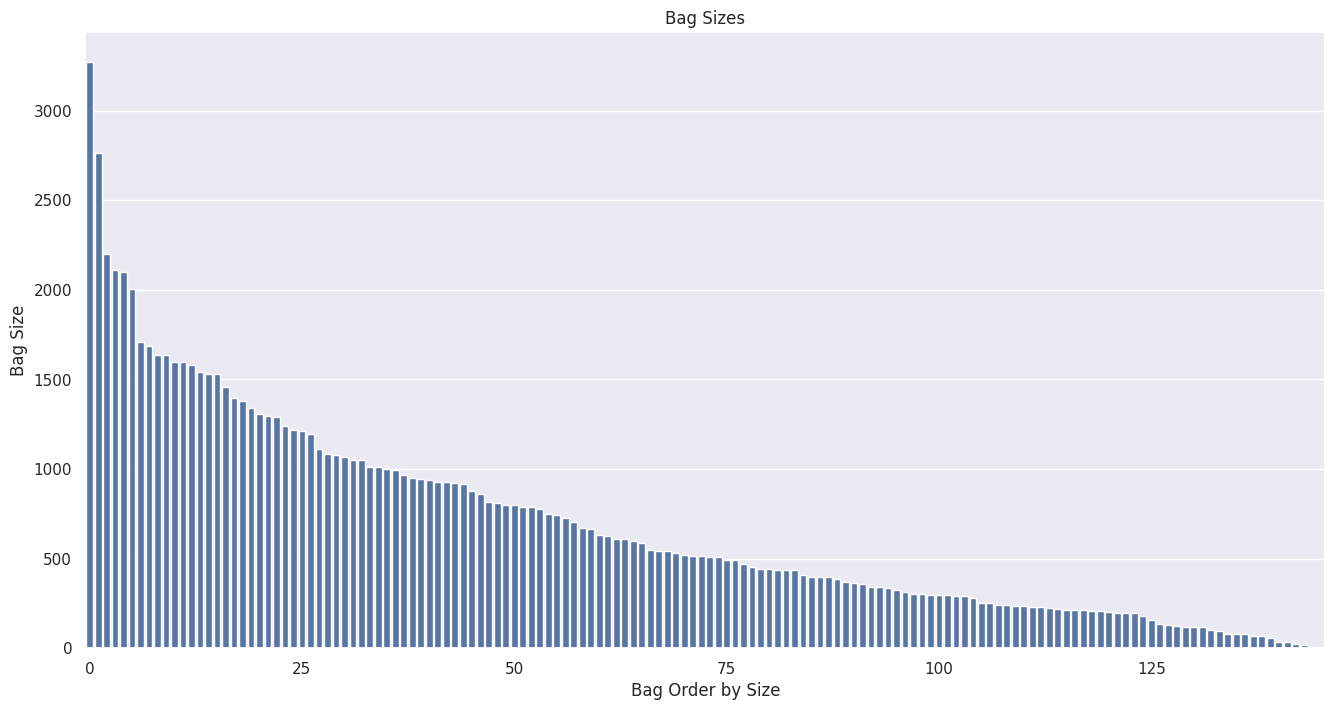

In [7]:
# patient id - 146 patients
adata.obs["sample"]
counts = adata.obs["sample"].value_counts()
index = np.arange(len(counts))
sns.set_theme()
fig, ax = plt.subplots(figsize=(16, 8))

sns.barplot(x=index, y=counts, ax=ax)

ax.set_title("Bag Sizes")
ax.set_xticks([25 * i for i in range(6)])
ax.set_ylabel("Bag Size")
ax.set_xlabel("Bag Order by Size")

In [8]:
y = adata.obs["lung_condition_coarse"]
print(y.unique())

f = lambda x: 0.0 if x == "Healthy" else 1.0
y_bin = np.array(y.apply(f))
np.savez(PROJECT_ROOT / "data/y.npz", y_bin)

['COVID-19', 'Healthy']
Categories (2, str): ['COVID-19', 'Healthy']


## Train Validation Test Split

In [9]:
patients = list(adata.obs["sample"].unique())
patients.sort()
index_patient_dict = dict()

for i in range(len(patients)):
    index_patient_dict[i] = patients[i]

patient_observations = adata.obs["sample"]
patient_observations = patient_observations.reset_index()

index_bag_dict = dict()
for i in index_patient_dict.keys():
    patient_id = index_patient_dict[i]
    patient_index = np.array(
        patient_observations[patient_observations["sample"] == patient_id].index
    )
    index_bag_dict[i] = patient_index

In [10]:
patient_observations

,index,sample
0,ATCTCTACATCACAGT-12_bharat,Sample_17
1,D367_Biop_Pro1_CGAGCACGTGCACGAA-1-28,D367_Biop_Pro1
2,02-P005175-S053-R01-AAGACAACATGAGAAT_delorey_n...,D1
3,AAAGATGGTGGCGAAT_GRO-09_biopsy,GRO-09_biopsy
4,TCACGCTGTATCCTCC-14_bharat,Sample_7
...,...,...
99995,ACTGAGTCAGTGAGTG-3_grant_fresh,Wunderink2021_sample_4
99996,12-P485759-S008-R01-CGGGCATGTTCCCAAA_delorey_n...,D14
99997,04-P103142-S109-R01-TCTTAGTGTGGAGAAA_delorey_n...,D12_2
99998,AGGATAACACGTACAT-18_bharat,Sample_19


In [11]:
test_proportion = 0.15
validation_proportion = 0.15
seed = 42


n = len(index_patient_dict.keys())
n_test = int(np.ceil(n * test_proportion))
n_val = int(np.ceil(n * validation_proportion))


rng = np.random.default_rng(seed=seed)
keys = list(index_patient_dict.keys())
idx_choice = rng.choice(a=keys, size=n_test + n_val, replace=False)

test_indices = idx_choice[:n_test]
validation_indices = idx_choice[n_test:]

Text(0.5, 1.0, 'Val Bag Sizes')

<Figure size 640x480 with 0 Axes>

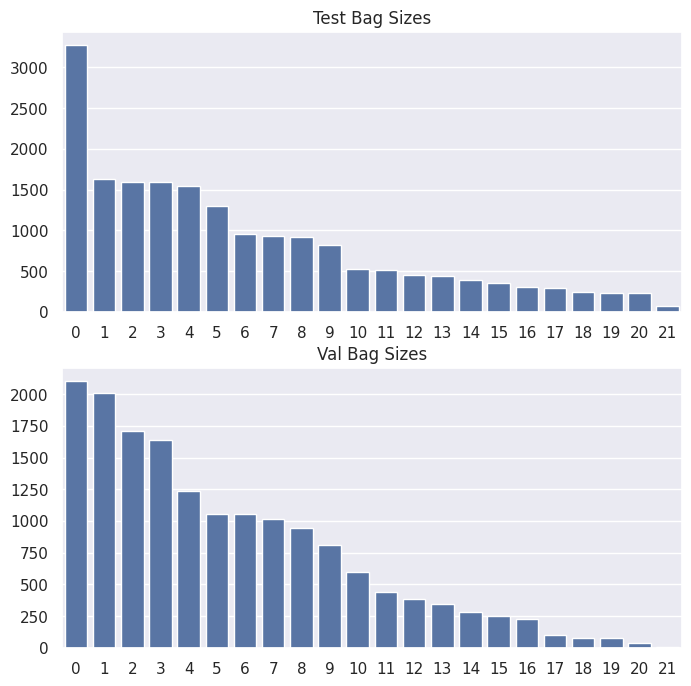

In [12]:
plt.tight_layout()
fig, ax = plt.subplots(2, figsize=(8, 8))
index = np.arange(n_test)

test_bags_sizes = [len(index_bag_dict[idx]) for idx in test_indices]
test_bags_sizes.sort(reverse=True)


val_bags_sizes = [len(index_bag_dict[idx]) for idx in validation_indices]
val_bags_sizes.sort(reverse=True)

sns.barplot(x=index, y=test_bags_sizes, ax=ax[0])
ax[0].set_title("Test Bag Sizes")
sns.barplot(x=index, y=val_bags_sizes, ax=ax[1])
ax[1].set_title("Val Bag Sizes")

In [13]:
index_split_dict = dict()
test_idx = 0
val_idx = 0
train_idx = 0

for i in list(index_patient_dict.keys()):
    if i in test_indices:
        index_split_dict[i] = ("test", test_idx)
        test_idx += 1
    elif i in validation_indices:
        index_split_dict[i] = ("val", val_idx)
        val_idx += 1
    else:
        index_split_dict[i] = ("train", train_idx)
        train_idx += 1

## Save Processed Data

In [14]:
log_data = np.log(X.data +1)
shape = X.shape

rows, cols = X.nonzero()

X_log = csr_matrix((log_data, (rows, cols)), shape = shape)

X_log_max = X_log.max(axis = 0).todense()
inverse_X_log_max = np.array(1/X_log_max).reshape(-1)
scaling = np.diag(inverse_X_log_max)

X_log_scaled = X_log@scaling

index = np.array((rows, cols))
X_log_scaled_data = X_log_scaled[rows, cols]

X_log_scaled = csr_matrix((X_log_scaled_data, (rows, cols)), shape = shape)

save_npz(PROJECT_ROOT / "data/X_log_scaled.npz", X_log_scaled)

x_embed = adata.obsm['embed']
np.savez(PROJECT_ROOT / 'data/x_embed.npz', x_embed)

In [15]:
dm = DatasetMeta(
    anndata_path=adata_path,
    processed_x_path="X_log_scaled.npz",
    x_embed_path="x_embed.npz",
    y_path="y.npz",
    index_patient_dict=index_patient_dict,
    index_bag_dict=index_bag_dict,
    index_split_dict=index_split_dict,
)
with open(PROJECT_ROOT / "data/dataset_meta.pcl", "wb") as f:
    pickle.dump(dm, f)

# Implementation Exploration - Torch Tensor Initialization

Text(0, 0.5, '# Nonzero Values')

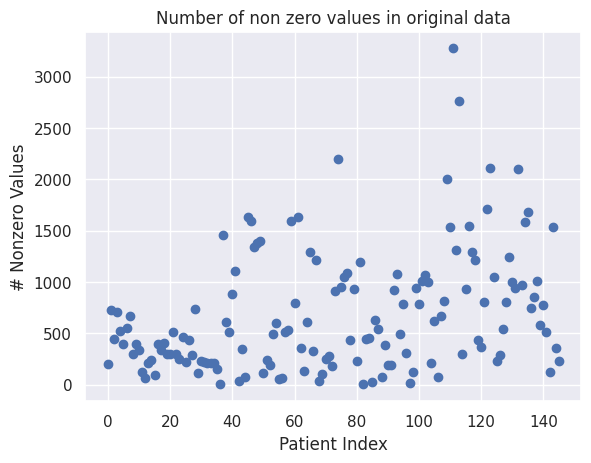

In [16]:
nonzero = list()

for key, bag_index in index_bag_dict.items():
    X_sub = X[bag_index, :]
    norm = X_sub @ X_sub.T
    n_nonzero = sum(norm.diagonal() > 0)
    nonzero.append((key, n_nonzero))

fig, ax = plt.subplots()

ax.scatter([el[0] for el in nonzero], [el[1] for el in nonzero])

ax.set_title("Number of non zero values in original data")
ax.set_xlabel("Patient Index")
ax.set_ylabel("# Nonzero Values")

/tmp/ipykernel_1622442/508011864.py:12: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  X_sub = torch.sparse_csr_tensor(rows, columns, data, size=shape)
/tmp/ipykernel_1622442/508011864.py:12: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  X_sub = torch.sparse_csr_tensor(rows, columns, data, size=shape)


Text(0, 0.5, '# Nonzero Values')

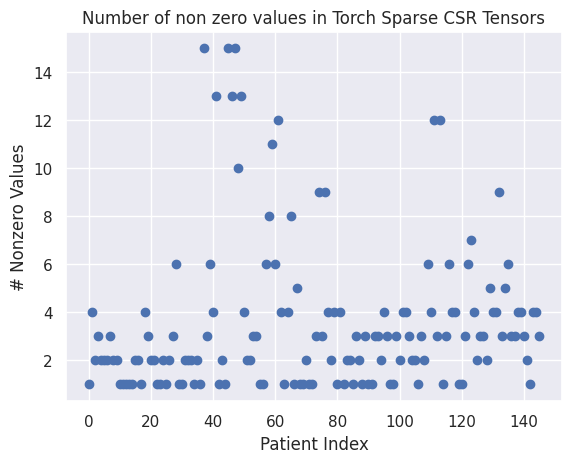

In [17]:
import torch


nonzero = list()

for key, bag_index in index_bag_dict.items():
    X_sub = adata.X[bag_index, :]
    rows, columns = X_sub.nonzero()
    data = X_sub.data

    shape = X_sub.shape
    X_sub = torch.sparse_csr_tensor(rows, columns, data, size=shape)
    X_sub = X_sub.to_dense()
    X_sub = X_sub.numpy()
    norm = np.diag(X_sub @ X_sub.T)

    n_nonzero = sum(norm > 0)
    nonzero.append((key, n_nonzero))


fig, ax = plt.subplots()

ax.scatter([el[0] for el in nonzero], [el[1] for el in nonzero])

ax.set_title("Number of non zero values in Torch Sparse CSR Tensors")
ax.set_xlabel("Patient Index")
ax.set_ylabel("# Nonzero Values")

Obviously, this is not great.


Text(0, 0.5, '# Nonzero Values')

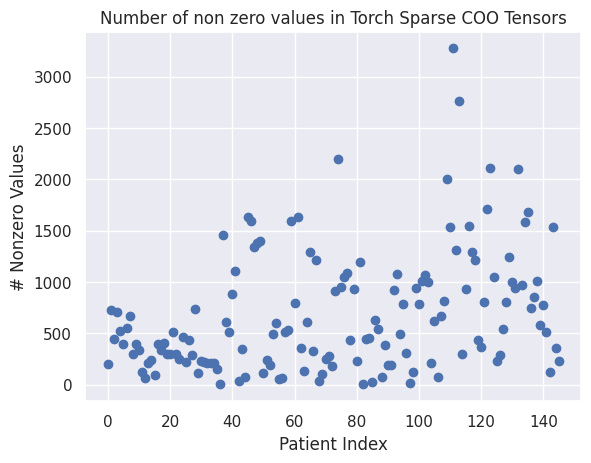

In [18]:
nonzero = list()

for key, bag_index in index_bag_dict.items():
    X_sub = adata.X[bag_index, :]

    coord = np.array(X_sub.nonzero())
    data = X_sub.data
    shape = X_sub.shape
    X_sub = torch.sparse_coo_tensor(coord, data, size=shape, dtype=torch.float32)

    X_sub = X_sub.to_dense()
    X_sub = X_sub.numpy()
    norm = np.diag(X_sub @ X_sub.T)

    n_nonzero = sum(norm > 0)
    nonzero.append((key, n_nonzero))


fig, ax = plt.subplots()

ax.scatter([el[0] for el in nonzero], [el[1] for el in nonzero])

ax.set_title("Number of non zero values in Torch Sparse COO Tensors")
ax.set_xlabel("Patient Index")
ax.set_ylabel("# Nonzero Values")